# Hyperparameter Tuning
Using GridSearchCV to tune the best model and plotting ROC curves

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import joblib
import warnings

warnings.filterwarnings('ignore')

train = pd.read_csv('../data/train_processed.csv')

FEATURES = ['Pclass', 'Sex_encoded', 'Age', 'FamilySize', 'IsAlone',
            'LogFare', 'Embarked_encoded', 'Title_encoded', 'AgeBand_encoded']

X = train[FEATURES]
y = train['Survived']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
# Grid Search on Random Forest
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X, y)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}
Best CV accuracy: 0.8361


In [8]:
# Best model
best_rf = grid_search.best_estimator_


joblib.dump(best_rf, '../models/best_model_rf.pkl')
print('Model saved to models/best_model_rf.pkl')

Model saved to models/best_model_rf.pkl


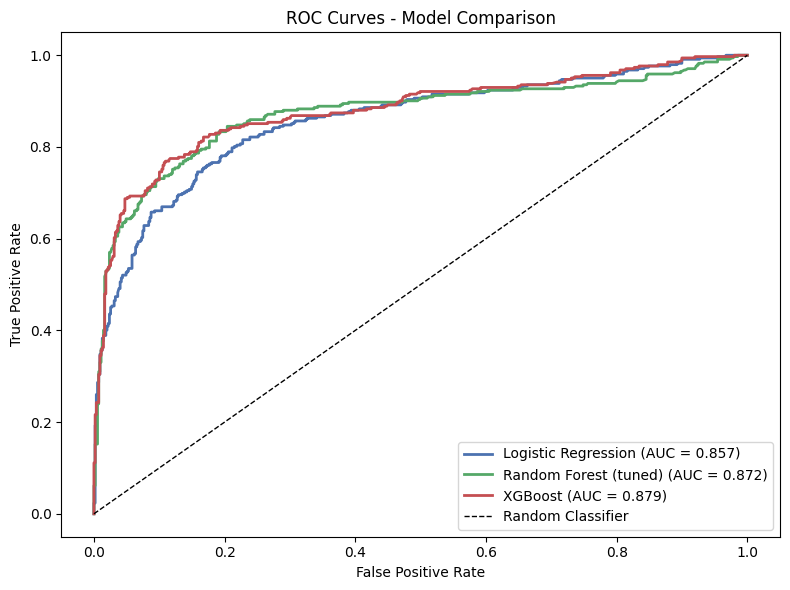

In [9]:
# ROC Curves for all models

# Get predicted probabilities via cross_val_predict
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(random_state=42, max_iter=500)
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                                random_state=42, use_label_encoder=False,
                                eval_metric='logloss', verbosity=0)

lr_probs = cross_val_predict(lr, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
rf_probs = cross_val_predict(best_rf, X, y, cv=cv, method='predict_proba')[:, 1]
xgb_probs = cross_val_predict(xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]

# Plot ROC curves
plt.figure(figsize=(8, 6))

for probs, name, color in [
    (lr_probs, 'Logistic Regression', '#4C72B0'),
    (rf_probs, 'Random Forest (tuned)', '#55A868'),
    (xgb_probs, 'XGBoost', '#C44E52')
]:
    fpr, tpr, _ = roc_curve(y, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../plots/roc_curves.png', dpi=150)
plt.show()

In [10]:
y_pred_best = best_rf.predict(X)
print('Best Model (Random Forest) - Training Report')
print(classification_report(y, y_pred_best, target_names=['Not Survived', 'Survived']))
print(f'\nBest CV Score: {grid_search.best_score_:.4f}')

Best Model (Random Forest) - Training Report
              precision    recall  f1-score   support

Not Survived       0.85      0.91      0.88       549
    Survived       0.84      0.74      0.79       342

    accuracy                           0.85       891
   macro avg       0.85      0.83      0.83       891
weighted avg       0.85      0.85      0.84       891


Best CV Score: 0.8361
